In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/atml_assignment0/task1'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
## checkpoint funcs for epochs

def save_checkpoint(model, optimizer, epoch, history, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }, path)
    print(f"Checkpoint saved: {path}")

def load_checkpoint(model, optimizer, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        print(f"Resumed from epoch {ckpt['epoch']}")
        return ckpt['epoch'], ckpt['history']
    return 0, {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

***TASK 1***

In [7]:
## TASK 1 

# loading model

model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
model = model.to(device=device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 143MB/s] 


Linear(in_features=2048, out_features=1000, bias=True)


In [8]:
## editing final fc layer + freezing backbone (excl fc)

CIFAR_NUM = 10

in_num = model.fc.in_features

for weightp in model.parameters():
    weightp.requires_grad = False

model.fc = nn.Linear(in_num, CIFAR_NUM)
model.fc = model.fc.to(device=device)

print(model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [9]:
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

DATA_DIR = '/content/drive/MyDrive/atml_assignment0/data'
os.makedirs(DATA_DIR, exist_ok=True)

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)


In [9]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=0.001, weight_decay=0.01)

In [10]:
EPOCHS = 5

start_epoch, history = load_checkpoint(model, optimizer, "baseline.pt")

for iter in range (start_epoch, EPOCHS):

    model.train()

    cur_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device=device)
        labels = labels.to(device=device)

        optimizer.zero_grad()
        image_pred = model(images)
        loss = loss_function(image_pred, labels)
        loss.backward()
        optimizer.step()

        cur_loss = cur_loss + (loss.item() * images.size(0))
        predicted_lab = image_pred.argmax(dim=1)
        correct += (predicted_lab == labels).sum().item()
        total += labels.size(0)

    train_loss = cur_loss / total
    train_acc = correct / total

    cur_loss = 0.0
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for images, labels in val_loader:
                    images = images.to(device=device)
                    labels = labels.to(device=device)
            
                    image_pred = model(images)
                    loss = loss_function(image_pred, labels)
            
                    cur_loss = cur_loss + (loss.item() * images.size(0))
                    predicted_lab = image_pred.argmax(dim=1)
                    correct += (predicted_lab == labels).sum().item()
                    total += labels.size(0)

    val_loss = cur_loss / total
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {iter+1}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    save_checkpoint(model, optimizer, iter+1, history, "baseline.pt")



Resumed from epoch 5


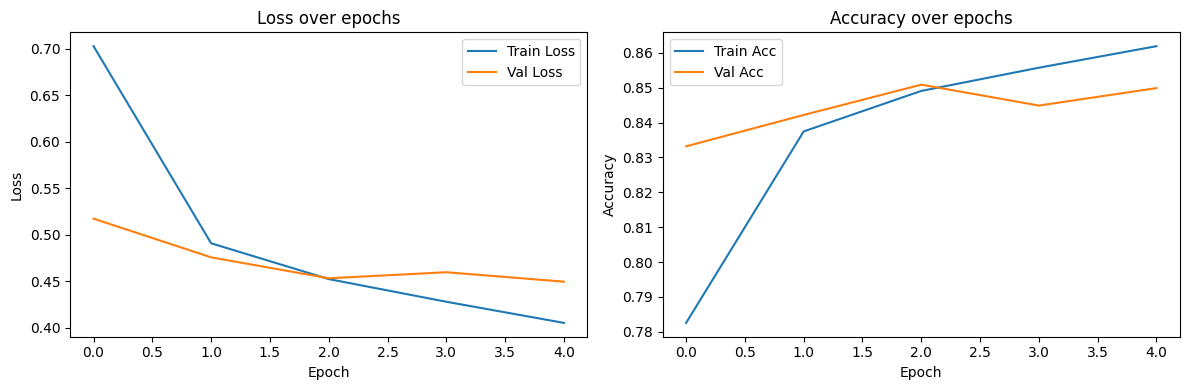

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss over epochs')

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy over epochs')

plt.tight_layout()
plt.show()

In [12]:
for epoch in range(len(history['train_loss'])):
    print(f"Epoch {epoch+1} | "
          f"Train Loss: {history['train_loss'][epoch]:.4f}, "
          f"Train Acc: {history['train_acc'][epoch]:.4f} | "
          f"Val Loss: {history['val_loss'][epoch]:.4f}, "
          f"Val Acc: {history['val_acc'][epoch]:.4f}")

Epoch 1 | Train Loss: 0.7029, Train Acc: 0.7825 | Val Loss: 0.5175, Val Acc: 0.8332
Epoch 2 | Train Loss: 0.4910, Train Acc: 0.8375 | Val Loss: 0.4759, Val Acc: 0.8422
Epoch 3 | Train Loss: 0.4525, Train Acc: 0.8491 | Val Loss: 0.4534, Val Acc: 0.8509
Epoch 4 | Train Loss: 0.4281, Train Acc: 0.8558 | Val Loss: 0.4599, Val Acc: 0.8449
Epoch 5 | Train Loss: 0.4054, Train Acc: 0.8619 | Val Loss: 0.4497, Val Acc: 0.8499


In [13]:
## TASK 1B

model_skip = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
model_skip = model_skip.to(device=device)

print(model_skip)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
def remove_skip(block):
    return nn.Sequential(block.conv1,
        block.bn1,
        nn.ReLU(),
        block.conv2,
        block.bn2,
        nn.ReLU(),
        block.conv3,
        block.bn3,
        nn.ReLU())

model_skip.layer1[1] = remove_skip(model_skip.layer1[1])
model_skip.layer2[5] = remove_skip(model_skip.layer2[5])
model_skip.layer3[11] = remove_skip(model_skip.layer3[11])

In [15]:

in_num = model_skip.fc.in_features

for weightp in model_skip.parameters():
    weightp.requires_grad = False

model_skip.fc = nn.Linear(in_num, CIFAR_NUM)
model_skip.fc = model_skip.fc.to(device=device)

print(model_skip.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [16]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_skip.fc.parameters(), lr=0.001, weight_decay=0.01)

In [17]:
EPOCHS = 5

start_epoch, history_skip = load_checkpoint(model_skip, optimizer, "no_skip.pt")

for iter in range (start_epoch, EPOCHS):

    model_skip.train()

    cur_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device=device)
        labels = labels.to(device=device)

        optimizer.zero_grad()
        image_pred = model_skip(images)
        loss = loss_function(image_pred, labels)
        loss.backward()
        optimizer.step()

        cur_loss = cur_loss + (loss.item() * images.size(0))
        predicted_lab = image_pred.argmax(dim=1)
        correct += (predicted_lab == labels).sum().item()
        total += labels.size(0)

    train_loss = cur_loss / total
    train_acc = correct / total

    cur_loss = 0.0
    correct = 0
    total = 0

    model_skip.eval()

    with torch.no_grad():
        for images, labels in val_loader:
                    images = images.to(device=device)
                    labels = labels.to(device=device)
            
                    image_pred = model_skip(images)
                    loss = loss_function(image_pred, labels)
            
                    cur_loss = cur_loss + (loss.item() * images.size(0))
                    predicted_lab = image_pred.argmax(dim=1)
                    correct += (predicted_lab == labels).sum().item()
                    total += labels.size(0)

    val_loss = cur_loss / total
    val_acc = correct / total

    history_skip['train_loss'].append(train_loss)
    history_skip['val_loss'].append(val_loss)
    history_skip['train_acc'].append(train_acc)
    history_skip['val_acc'].append(val_acc)

    print(f"Epoch {iter+1}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    save_checkpoint(model_skip, optimizer, iter+1, history_skip, "no_skip.pt")



Resumed from epoch 5


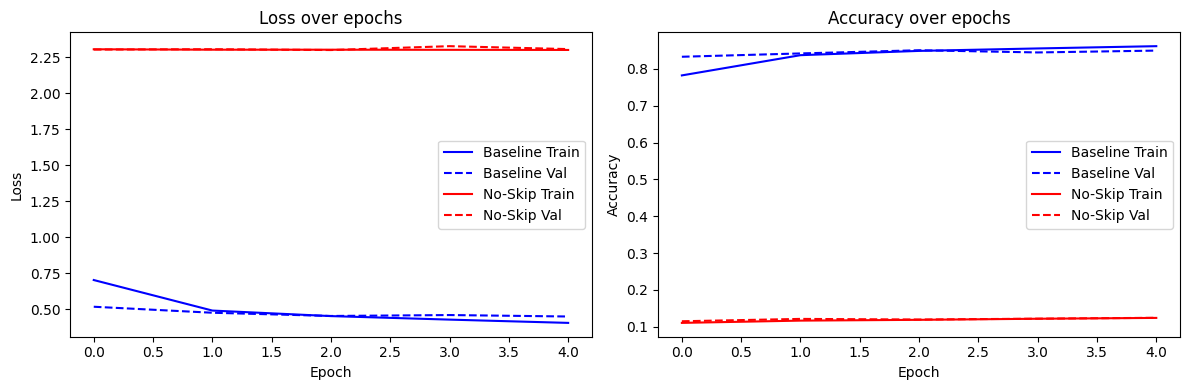

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], 'b-', label='Baseline Train')
axes[0].plot(history['val_loss'], 'b--', label='Baseline Val')
axes[0].plot(history_skip['train_loss'], 'r-', label='No-Skip Train')
axes[0].plot(history_skip['val_loss'], 'r--', label='No-Skip Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss over epochs')

axes[1].plot(history['train_acc'], 'b-', label='Baseline Train')
axes[1].plot(history['val_acc'], 'b--', label='Baseline Val')
axes[1].plot(history_skip['train_acc'], 'r-', label='No-Skip Train')
axes[1].plot(history_skip['val_acc'], 'r--', label='No-Skip Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy over epochs')

plt.tight_layout()
plt.show()

In [19]:
features = {}
import torch.nn.functional as F

def save_features(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

model.layer1.register_forward_hook(save_features("layer1"))
model.layer2.register_forward_hook(save_features("layer2"))
model.layer3.register_forward_hook(save_features("layer3"))
model.layer4.register_forward_hook(save_features("layer4"))

model.eval()

layer_names = ["layer1", "layer2", "layer3", "layer4"]
feat_total = {name: [] for name in layer_names}

totallabels = []

LIMIT = 2000
counter = 0

with torch.no_grad():
    for images, labels in val_loader:
        if counter >= LIMIT:
            break

        images = images.to(device)
        pred_labels = model(images)

        for name in layer_names:
            feat = features[name]
            feat_pool = F.adaptive_avg_pool2d(feat, 1).flatten(1)
            feat_total[name].append(feat_pool.cpu())

        totallabels.append(labels)

        counter += images.size(0)

    for name in layer_names:
        feat_total[name] = torch.cat(feat_total[name], dim=0)[:LIMIT]

    totallabels = torch.cat(totallabels, dim=0)[:LIMIT]

    print("Collected:", LIMIT, "samples")
    for name in layer_names:
        print(name, feat_total[name].shape)


Collected: 2000 samples
layer1 torch.Size([2000, 256])
layer2 torch.Size([2000, 512])
layer3 torch.Size([2000, 1024])
layer4 torch.Size([2000, 2048])


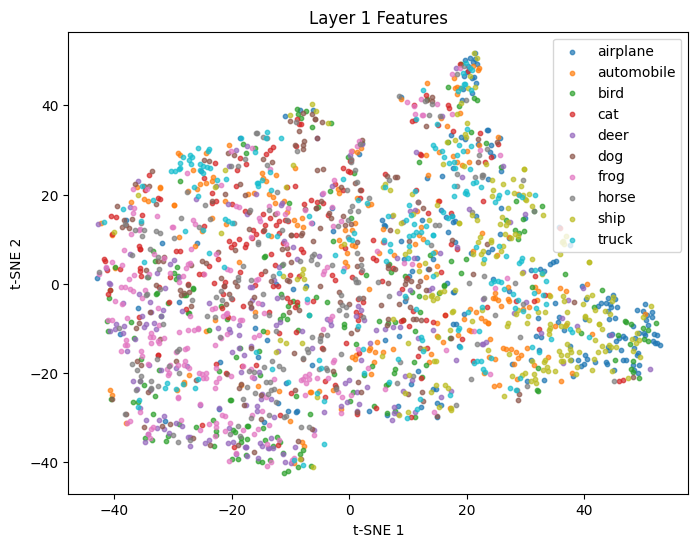

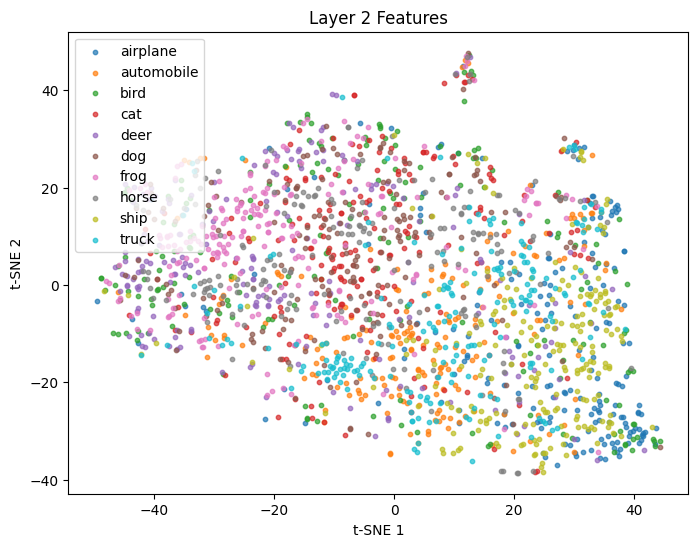

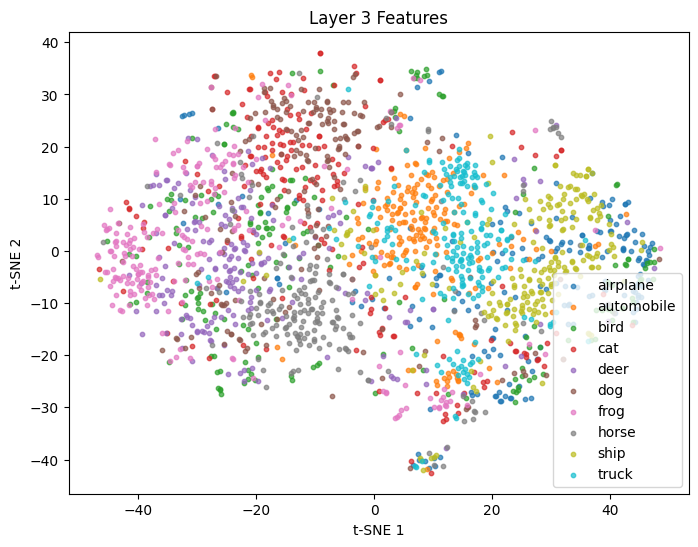

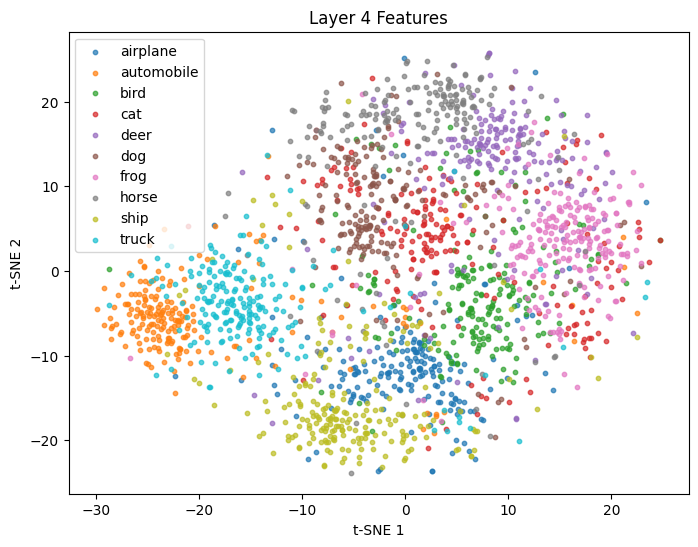

In [20]:
from sklearn.manifold import TSNE

def plot_tsne(X, labels, title):
    class_names = train_dataset.classes
    tsne = TSNE( n_components=2, random_state=2, perplexity=30)

    tsne_2d = tsne.fit_transform(X.cpu().numpy())

    plt.figure(figsize=(8, 6))

    for class_idx in range(len(class_names)):
        mask = labels.cpu().numpy() == class_idx
        plt.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], label=class_names[class_idx], s=10, alpha=0.7)


    plt.legend()
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

plot_tsne(feat_total["layer1"], totallabels, "Layer 1 Features")
plot_tsne(feat_total["layer2"], totallabels, "Layer 2 Features")
plot_tsne(feat_total["layer3"], totallabels, "Layer 3 Features")
plot_tsne(feat_total["layer4"], totallabels, "Layer 4 Features")


In [21]:
from torch.utils.data import Subset
import numpy as np

np.random.seed(42)

subset_indices = np.random.choice(len(train_dataset), size=10000, replace=False)

train_dataset_subset = Subset(train_dataset, subset_indices)

train_loader_subset = DataLoader(train_dataset_subset, batch_size=64, shuffle=True, num_workers=2)

In [22]:
def model_create(pretrained, unfreeze_full_backbone):

    if pretrained:
        weights = models.ResNet152_Weights.DEFAULT
    else: 
        weights = None

    model = models.resnet152(weights=weights)
    model = model.to(device)

    if unfreeze_full_backbone:
        for param in model.parameters():
            param.requires_grad = True
    else:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, 10)
    model.fc = model.fc.to(device)

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

pretrained_block = model_create(pretrained=True,  unfreeze_full_backbone=False)
pretrained_full = model_create(pretrained=True,  unfreeze_full_backbone=True)
random_block = model_create(pretrained=False, unfreeze_full_backbone=False)
random_full = model_create(pretrained=False, unfreeze_full_backbone=True)

In [23]:
optimizer1 = optim.AdamW( filter(lambda p: p.requires_grad, pretrained_block.parameters()), lr=0.001, weight_decay=0.01)

backbone_params_2 = []
for name, module in pretrained_full.named_children():
    if name != 'fc':
        backbone_params_2.extend(module.parameters())

optimizer2 = optim.AdamW([{'params': backbone_params_2, 'lr': 0.0001}, {'params': pretrained_full.fc.parameters(), 'lr': 0.001}], weight_decay=0.01)

optimizer3 = optim.AdamW( filter(lambda p: p.requires_grad, random_block.parameters()), lr=0.001, weight_decay=0.01)

optimizer4 = optim.AdamW(random_full.parameters(), lr=0.0005, weight_decay=0.01)

In [24]:
loss_function = nn.CrossEntropyLoss()

In [25]:
def train_model(model, optimizer, train_loader, val_loader, epochs, pt_name):
    start_epoch, history = load_checkpoint(model, optimizer, pt_name)
    print(pt_name)
    for iter in range (start_epoch, epochs):
        
        model.train()

        cur_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            image_pred = model(images)
            loss = loss_function(image_pred, labels)
            loss.backward()
            optimizer.step()

            cur_loss = cur_loss + (loss.item() * images.size(0))
            predicted_lab = image_pred.argmax(dim=1)
            correct += (predicted_lab == labels).sum().item()
            total += labels.size(0)

        train_loss = cur_loss / total
        train_acc = correct / total

        cur_loss = 0.0
        correct = 0
        total = 0

        model.eval()

        with torch.no_grad():
            for images, labels in val_loader:
                    images = images.to(device=device)
                    labels = labels.to(device=device)
            
                    image_pred = model(images)
                    loss = loss_function(image_pred, labels)
            
                    cur_loss = cur_loss + (loss.item() * images.size(0))
                    predicted_lab = image_pred.argmax(dim=1)
                    correct += (predicted_lab == labels).sum().item()
                    total += labels.size(0)

        val_loss = cur_loss / total
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {iter+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        save_checkpoint(model, optimizer, iter+1, history, pt_name)

    return history


EPOCHS = 5

history2 = train_model(pretrained_full, optimizer2, train_loader_subset, val_loader, EPOCHS, "pretrained_full.pt")

history4 = train_model(random_full, optimizer4, train_loader_subset, val_loader, EPOCHS, "random_full.pt")

history1 = train_model(pretrained_block, optimizer1, train_loader_subset, val_loader, EPOCHS, "pretrained_block.pt")

history3 = train_model(random_block, optimizer3, train_loader_subset, val_loader, EPOCHS, "random_block.pt")


Resumed from epoch 5
pretrained_full.pt
Resumed from epoch 5
random_full.pt
Resumed from epoch 5
pretrained_block.pt
Resumed from epoch 5
random_block.pt


Config                         Final Val Acc  
Pretrained + Final-block       0.8755         
Pretrained + Full backbone     0.9441         
Random init + Final-block      0.2913         
Random init + Full backbone    0.5083         


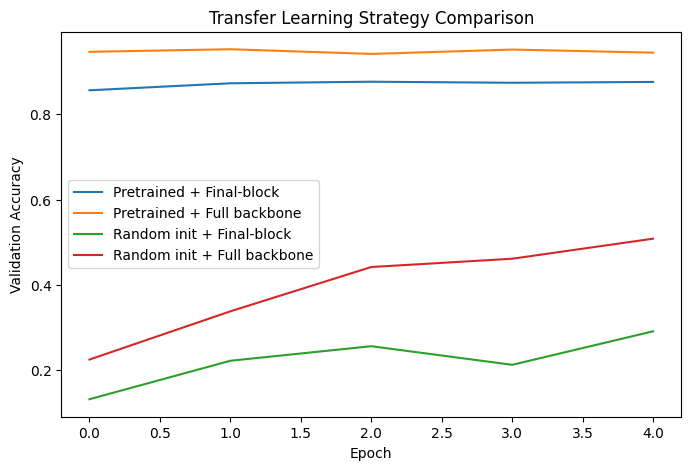

In [26]:

results = { "Pretrained + Final-block": history1, "Pretrained + Full backbone": history2, "Random init + Final-block": history3, "Random init + Full backbone": history4,}

print(f"{'Config':<30} {'Final Val Acc':<15}")
for name, hist in results.items():
    print(f"{name:<30} {hist['val_acc'][-1]:<15.4f}")

plt.figure(figsize=(8,5))
for name, hist in results.items():
    plt.plot(hist['val_acc'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Transfer Learning Strategy Comparison')
plt.legend()
plt.show()

***TASK 2***

In [4]:
from transformers import ViTForImageClassification, ViTImageProcessor

In [5]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224', attn_implementation="eager")
vit_model = vit_model.to(device)
vit_model.eval()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

True label: cat


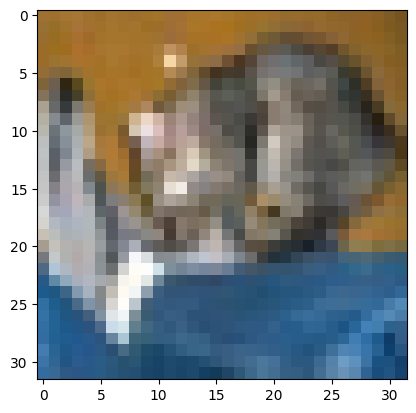

True label: ship


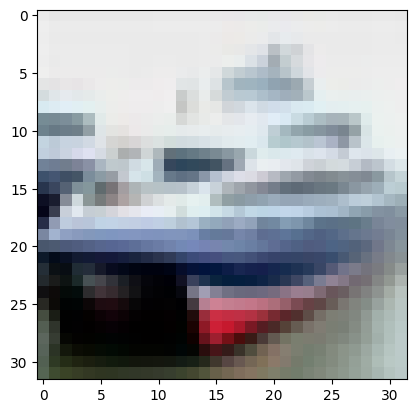

True label: ship


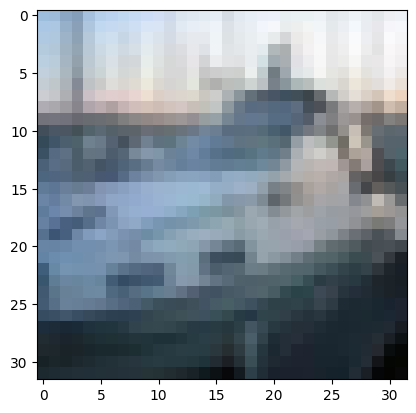

In [10]:
cifar_data = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

vit_image = []
vit_label = []

for i in range(0,3):
    vit_image.append(cifar_data[i][0])
    vit_label.append(cifar_data[i][1])

class_names = cifar_data.classes

for img, label in zip(vit_image, vit_label):
    print("True label:", class_names[label])
    plt.figure()
    plt.imshow(img)  
    plt.show()

In [18]:
image_pred_label = []

for image in vit_image:
    vit_input = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        vit_output = vit_model(**vit_input)
        logits = vit_output.logits
        probs = torch.softmax(logits, dim=1)
        confidence = probs.max(dim=1)
        print(confidence)
        class_pred = logits.argmax(-1).item()
        print("ViT prediction:", vit_model.config.id2label[class_pred])
        image_pred_label.append(vit_model.config.id2label[class_pred])


torch.return_types.max(
values=tensor([0.1773], device='cuda:0'),
indices=tensor([281], device='cuda:0'))
ViT prediction: tabby, tabby cat
torch.return_types.max(
values=tensor([0.5436], device='cuda:0'),
indices=tensor([814], device='cuda:0'))
ViT prediction: speedboat
torch.return_types.max(
values=tensor([0.3651], device='cuda:0'),
indices=tensor([814], device='cuda:0'))
ViT prediction: speedboat


Predicted label: tabby, tabby cat


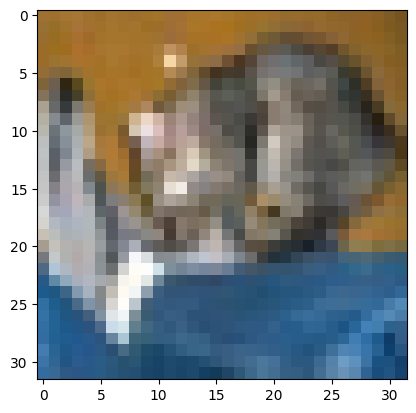

Predicted label: speedboat


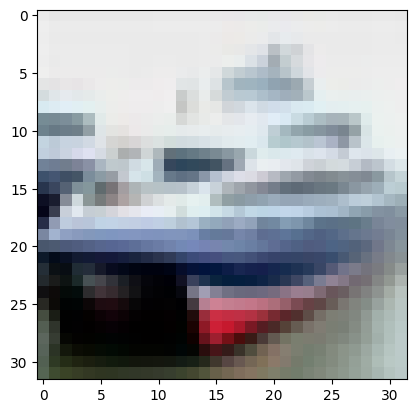

Predicted label: speedboat


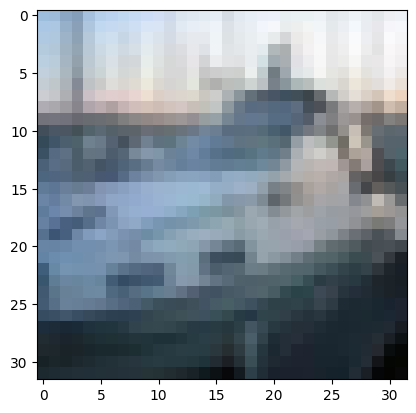

In [31]:
for img, label in zip(vit_image, image_pred_label):
    print("Predicted label:", label)
    plt.figure()
    plt.imshow(img)  
    plt.show()

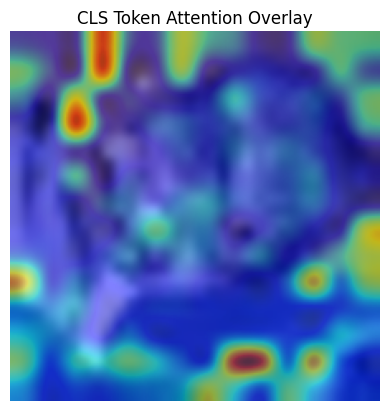

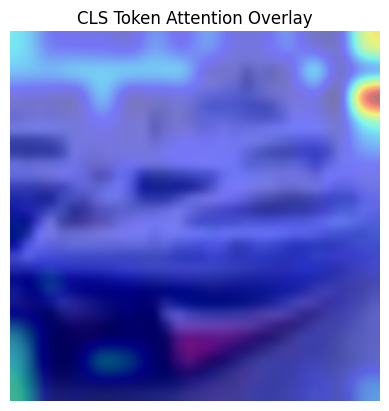

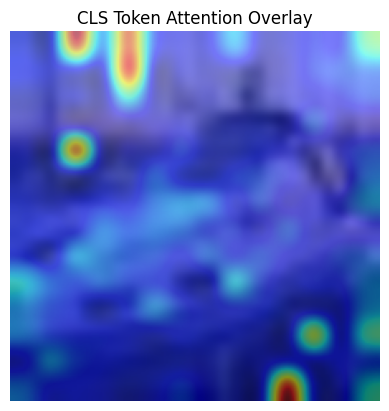

In [32]:
from PIL import Image
import numpy as np

for image in vit_image:
    vit_input = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        vit_output = vit_model(**vit_input, output_attentions=True)
        attentions = vit_output.attentions  
        final_layer_attention = attentions[-1]
        avg_attention_head = final_layer_attention.mean(dim=1)
        cls_attention = avg_attention_head[0, 0, 1:]
        attention_map = cls_attention.reshape(14, 14).cpu().numpy()

        attention_map_resized = np.array(Image.fromarray(attention_map).resize((224, 224), resample=Image.BICUBIC))

        img_resized = image.resize((224, 224))

        plt.imshow(img_resized)
        plt.imshow(attention_map_resized, cmap='jet', alpha=0.5)
        plt.axis('off')
        plt.title('CLS Token Attention Overlay')
        plt.show()


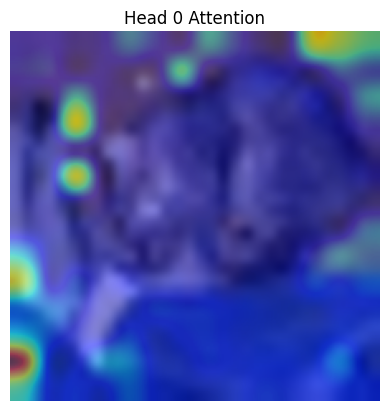

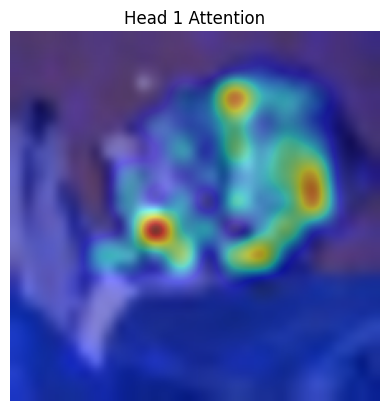

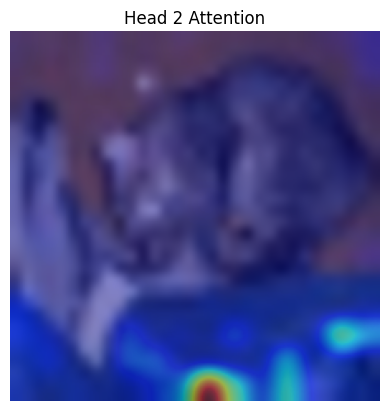

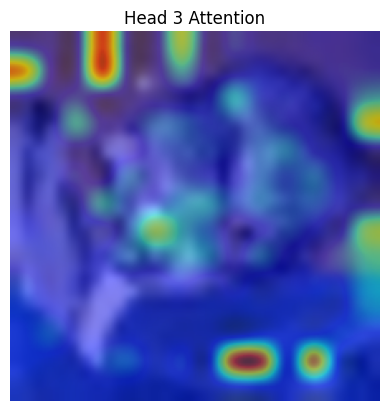

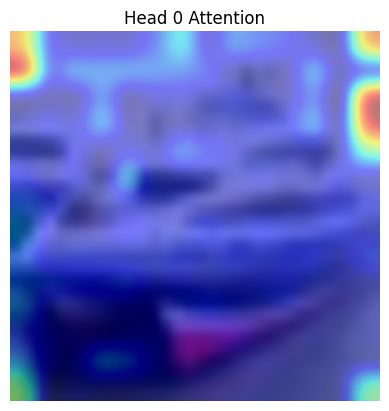

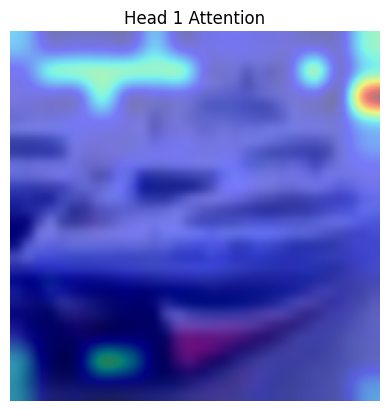

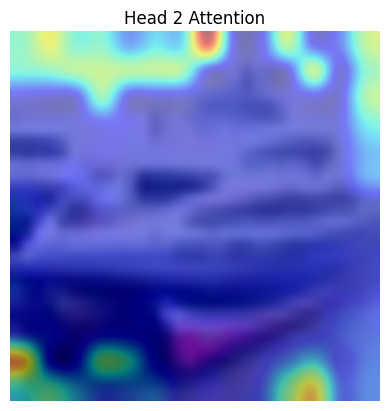

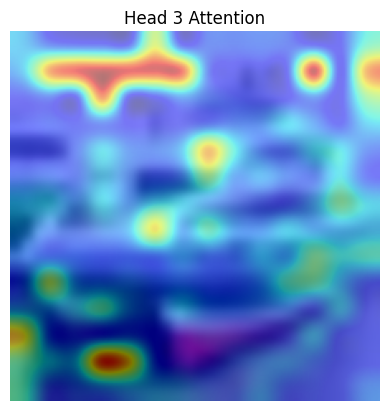

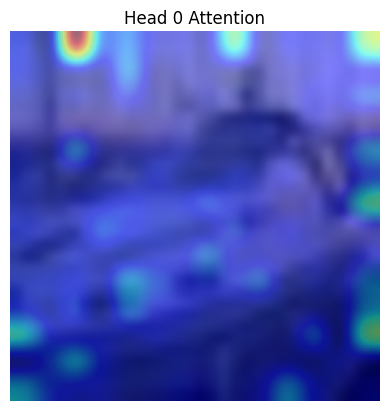

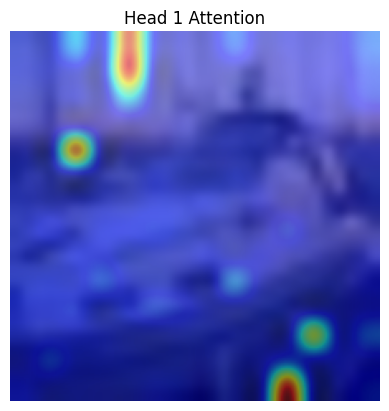

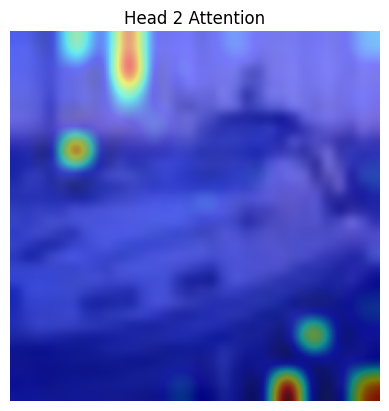

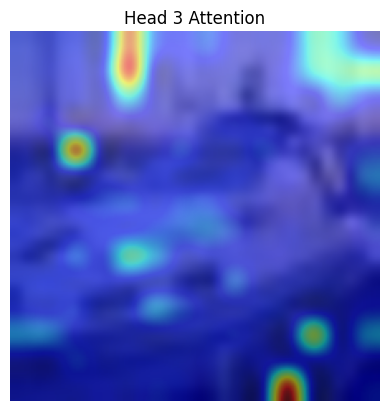

In [33]:
NUM_HEADS_TO_SHOW = 4  

for image in vit_image:
    vit_input = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        vit_output = vit_model(**vit_input, output_attentions=True)
        attentions = vit_output.attentions
        final_layer_attention = attentions[-1]  # shape [1, 12, 197, 197]

        img_resized = image.resize((224, 224))

        for head_idx in range(NUM_HEADS_TO_SHOW):
            head_attention = final_layer_attention[0, head_idx, 0, 1:]
            attention_map = head_attention.reshape(14, 14).cpu().numpy()

            attention_map_resized = np.array(Image.fromarray(attention_map).resize((224, 224), resample=Image.BICUBIC))

            plt.imshow(img_resized)
            plt.imshow(attention_map_resized, cmap='jet', alpha=0.5)
            plt.axis('off')
            plt.title(f'Head {head_idx} Attention')
            plt.show()

In [34]:
np.random.seed(71)
NUM = 200
test_indices = np.random.choice(len(cifar_data), size=NUM, replace=False)

test_images = [cifar_data[i][0] for i in test_indices]  
baseline_pred = []

for img in test_images:
    inputs = processor(images=img, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = vit_model(**inputs)
        pred_idx = outputs.logits.argmax(-1).item()
        baseline_pred.append(pred_idx)

In [35]:
image_size = 224
patch_size = 16

def random_patch_mask(images, mask_fraction):

    masked = images.clone()

    B, C, H, W = masked.shape

    grid_size = H // patch_size

    total_patches = grid_size ** 2
    num_mask = int(total_patches * mask_fraction)

    for b in range(B):
        indices = torch.randperm(total_patches)[:num_mask]

        for idx in indices:
            row = idx // grid_size
            col = idx % grid_size

            h1 = row * patch_size
            h2 = h1 + patch_size

            w1 = col * patch_size
            w2 = w1 + patch_size

            masked[b, :, h1:h2, w1:w2] = 0

    return masked


def cetre_patch_mask(images, mask_fraction):
    masked = images.clone()

    B, C, H, W = masked.shape

    grid_size = H // patch_size

    total_patches = grid_size ** 2
    num_mask = int(total_patches * mask_fraction)

    target = int(total_patches * mask_fraction)

    side = int(np.floor(np.sqrt(target)))

    side = max(1, min(side, grid_size))

    start = (grid_size - side) // 2
    end = start + side

    h1 = start * patch_size
    h2 = end * patch_size

    w1 = start * patch_size
    w2 = end * patch_size

    masked[:, :, h1:h2, w1:w2] = 0

    return masked

def mask_acc(baseline_pred, masked_pred):
    baseline_pred = np.array(baseline_pred)
    masked_pred = np.array(masked_pred)
    return (baseline_pred == masked_pred).sum() / len(baseline_pred)

In [36]:
inputs = processor( images=test_images, return_tensors="pt")

images_tensor = inputs["pixel_values"].to(device)

mask_fractions = [0.0, 0.10, 0.25, 0.50, 0.75]

random_results = []
center_results = []

for fraction in mask_fractions:

    random_images = random_patch_mask(images_tensor, fraction)

    with torch.no_grad():
        outputs = vit_model(pixel_values=random_images)
        random_pred = outputs.logits.argmax(dim=-1).cpu().numpy()

    random_results.append(mask_acc(baseline_pred, random_pred))

    center_images = cetre_patch_mask(images_tensor, fraction)

    with torch.no_grad():
        outputs = vit_model(pixel_values=center_images)
        center_pred = outputs.logits.argmax(dim=-1).cpu().numpy()

    center_results.append(mask_acc(baseline_pred, center_pred))

    print(
        f"{fraction*100:.0f}% masked | "
        f"Random: {random_results[-1]:.3f} | "
        f"Center: {center_results[-1]:.3f}"
    )

0% masked | Random: 1.000 | Center: 0.925
10% masked | Random: 0.735 | Center: 0.645
25% masked | Random: 0.620 | Center: 0.330
50% masked | Random: 0.315 | Center: 0.200
75% masked | Random: 0.075 | Center: 0.095


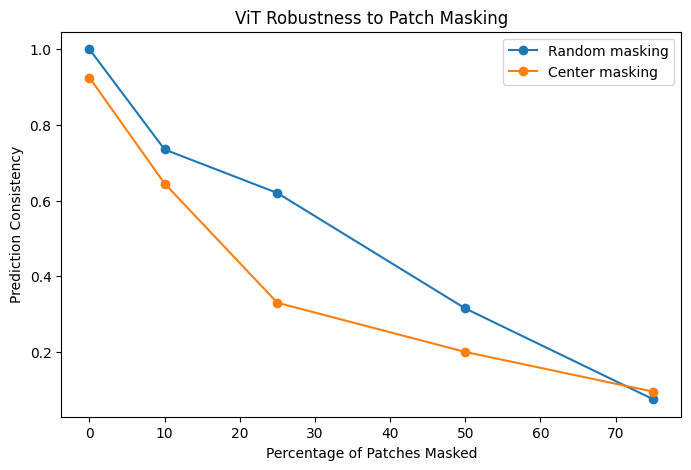

In [37]:
mask_percentages = [f * 100 for f in mask_fractions]

plt.figure(figsize=(8, 5))

plt.plot(mask_percentages, random_results, marker="o", label="Random masking")
plt.plot(mask_percentages, center_results, marker="o", label="Center masking")

plt.xlabel("Percentage of Patches Masked")
plt.ylabel("Prediction Consistency")
plt.title("ViT Robustness to Patch Masking")
plt.legend()
plt.show()

In [78]:
transform=transforms.ToTensor()

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

In [79]:
def extract_features(loader):

    vit_model.eval()

    cls_features = []
    mean_features = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = [transforms.ToPILImage()(img)
                for img in images]

            inputs = processor( images=list(images), return_tensors="pt")

            pixel_values = inputs["pixel_values"].to(device)

            outputs = vit_model.vit(pixel_values=pixel_values)

            tokens = outputs.last_hidden_state

            cls = tokens[:, 0, :]

            mean_out = tokens[:, 1:, :].mean(dim=1)

            cls_features.append(cls.cpu())
            mean_features.append(mean_out.cpu())
            labels_all.append(labels)

    return torch.cat(cls_features), torch.cat(mean_features), torch.cat(labels_all)

train_cls, train_mean, train_labels = extract_features(train_loader)

test_cls, test_mean, test_labels = extract_features(val_loader)


    

In [80]:
def train_linear_probe(train_features, train_labels, test_features, test_labels, epochs=10):

    input_dim = train_features.shape[1]

    probe = nn.Linear(input_dim, 10).to(device)

    optimizer = optim.Adam(probe.parameters(),lr=1e-3)

    criterion = nn.CrossEntropyLoss()

    train_features = train_features.to(device)
    train_labels = train_labels.to(device)

    test_features = test_features.to(device)
    test_labels = test_labels.to(device)

    for epoch in range(epochs):

        probe.train()

        optimizer.zero_grad()

        logits = probe(train_features)

        loss = criterion(logits, train_labels)

        loss.backward()
        optimizer.step()

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Loss: {loss.item():.4f}"
        )

    probe.eval()

    with torch.no_grad():

        logits = probe(test_features)

        predictions = logits.argmax(dim=1)

        accuracy = (predictions == test_labels).float().mean().item()

    return probe, accuracy

cls_probe, cls_accuracy = train_linear_probe(train_cls, train_labels, test_cls, test_labels)

print(f"CLS accuracy: {cls_accuracy * 100:.2f}%")

mean_probe, mean_accuracy = train_linear_probe(train_mean, train_labels, test_mean, test_labels)

print(f"Mean-pooling accuracy: {mean_accuracy * 100:.2f}%")

Epoch 1/10 Loss: 2.5036
Epoch 2/10 Loss: 2.2323
Epoch 3/10 Loss: 1.9780
Epoch 4/10 Loss: 1.7420
Epoch 5/10 Loss: 1.5255
Epoch 6/10 Loss: 1.3295
Epoch 7/10 Loss: 1.1546
Epoch 8/10 Loss: 1.0008
Epoch 9/10 Loss: 0.8678
Epoch 10/10 Loss: 0.7543
CLS accuracy: 92.45%
Epoch 1/10 Loss: 2.4225
Epoch 2/10 Loss: 2.2210
Epoch 3/10 Loss: 2.0275
Epoch 4/10 Loss: 1.8433
Epoch 5/10 Loss: 1.6694
Epoch 6/10 Loss: 1.5069
Epoch 7/10 Loss: 1.3569
Epoch 8/10 Loss: 1.2198
Epoch 9/10 Loss: 1.0959
Epoch 10/10 Loss: 0.9851
Mean-pooling accuracy: 91.46%


***TASK 3***

In [41]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ie5jn2e6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ie5jn2e6
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1a4bf02449c1214bc4e334f629582c98b091bd48cb3c8baaf8a6e05a37165462
  Stored in directory: /tmp/pip-ephem-wheel-cache-tnf8ekuh/wheels/cb/a8/74/5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfully built clip


In [42]:
import clip
from torchvision.datasets import STL10
from torch.utils.data import DataLoader

In [43]:
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

classes = [ "airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

dataset = STL10( root="./data", split="test", download=True, transform=preprocess)

loader = DataLoader( dataset, batch_size=64, shuffle=False, num_workers=2)

print("Test images:", len(dataset))

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 60.3MiB/s]
100%|██████████| 2.64G/2.64G [01:50<00:00, 23.9MB/s]


Test images: 8000


In [44]:
plain_label = classes

prompted_text = []

for c in classes:
    prompted_text.append(f"a photo of a {c}")


prompts_descriptive = [
    "a photo of an airplane, a vehicle",
    "a photo of a bird, an animal",
    "a photo of a car, a vehicle",
    "a photo of a cat, an animal",
    "a photo of a deer, an animal",
    "a photo of a dog, an animal",
    "a photo of a horse, an animal",
    "a photo of a monkey, an animal",
    "a photo of a ship, a vehicle",
    "a photo of a truck, a vehicle"
]

In [45]:
def evaluate(prompts):

    text = clip.tokenize(prompts).to(device)

    with torch.no_grad():
        text_features = model.encode_text(text)

    text_features /= text_features.norm(dim=-1, keepdim=True)

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            image_features = model.encode_image(images)

            image_features /= image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T

            predictions = similarity.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy


accuracy_plain = evaluate(plain_label)

accuracy_photo = evaluate(prompted_text)

accuracy_descriptive = evaluate(prompts_descriptive)

In [46]:
print(f"Plain labels:       {accuracy_plain:.2f}%")
print(f"Prompted text:       {accuracy_photo:.2f}%")
print(f"Descriptive prompt: {accuracy_descriptive:.2f}%")

Plain labels:       96.26%
Prompted text:       97.36%
Descriptive prompt: 95.91%


In [47]:
images, labels = next(iter(loader))

images = images[:50]
labels = labels[:50]

images = images.to(device)

with torch.no_grad():

    image_features = model.encode_image(images)

texts = [classes[label.item()] for label in labels]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)    


In [48]:
image_features_raw = image_features.cpu()
text_features_raw = text_features.cpu()

image_features_norm = image_features / image_features.norm( dim=-1, keepdim=True)

text_features_norm = text_features / text_features.norm( dim=-1, keepdim=True)

image_features_norm = image_features_norm.cpu()
text_features_norm = text_features_norm.cpu()

In [49]:
embeddings = torch.cat([image_features_raw, text_features_raw]).numpy()

tsne_orig = TSNE(n_components=2, random_state=71, perplexity=15)

orig_2d = tsne_orig.fit_transform(embeddings)

norm_embeddings = torch.cat([ image_features_norm, text_features_norm]).numpy()

tsne_norm = TSNE( n_components=2, random_state=71, perplexity=15)

norm_2d = tsne_norm.fit_transform(norm_embeddings)

modality = (["Image"] * 50 + ["Text"] * 50)

class_labels = [classes[label.item()] for label in labels]

class_labels = class_labels + class_labels

In [50]:
colors = plt.cm.tab10(np.arange(10))

def plot_embeddings(embeddings_2d, title):

    plt.figure(figsize=(10, 8))

    for class_id, class_name in enumerate(classes):

        class_indices = [i for i, label in enumerate(class_labels) if label == class_name]

        image_indices = [i for i in class_indices if modality[i] == "Image"]

        text_indices = [i for i in class_indices if modality[i] == "Text"]

        plt.scatter(embeddings_2d[image_indices, 0], embeddings_2d[image_indices, 1], color=colors[class_id], marker="o", s=70, label=f"{class_name} - Image")

        plt.scatter( embeddings_2d[text_indices, 0], embeddings_2d[text_indices, 1], color=colors[class_id], marker="^", s=90, edgecolors="black", label=f"{class_name} - Text")

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend( bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

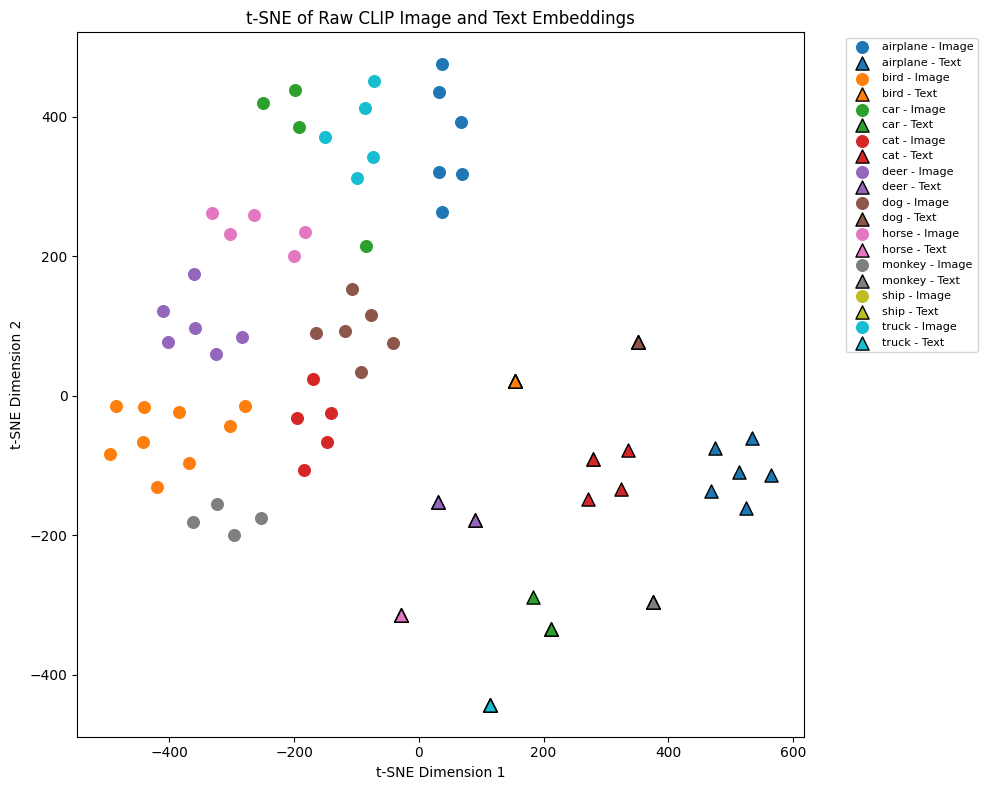

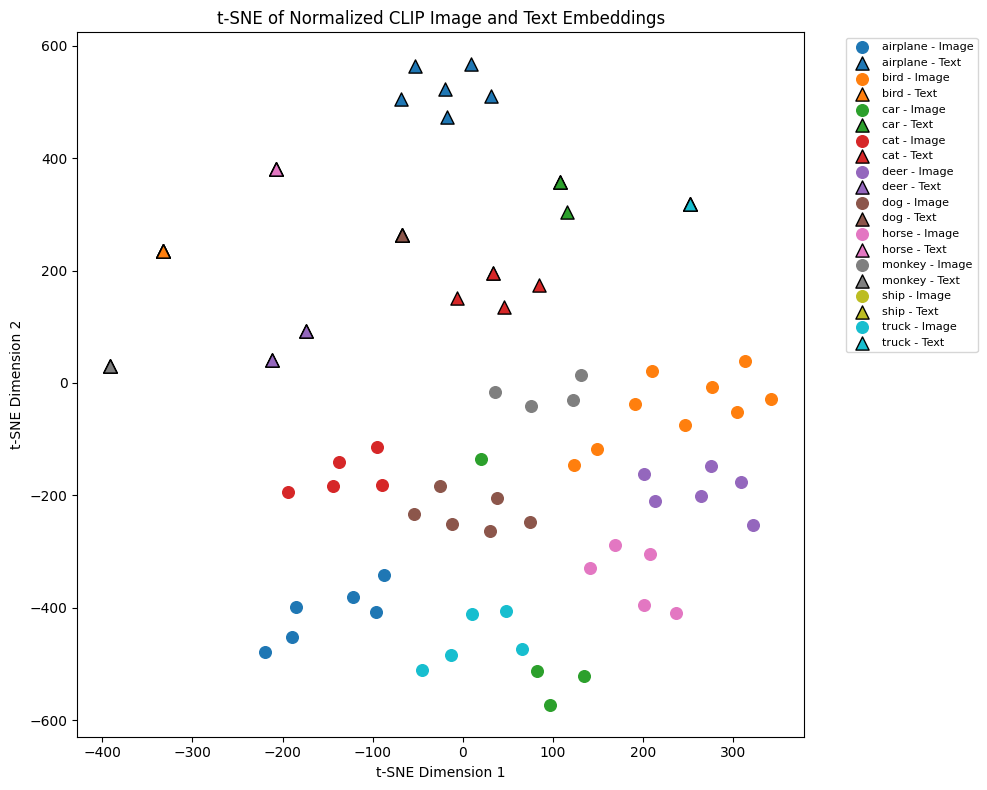

In [51]:
plot_embeddings(orig_2d, "t-SNE of Raw CLIP Image and Text Embeddings")

plot_embeddings(norm_2d, "t-SNE of Normalized CLIP Image and Text Embeddings")

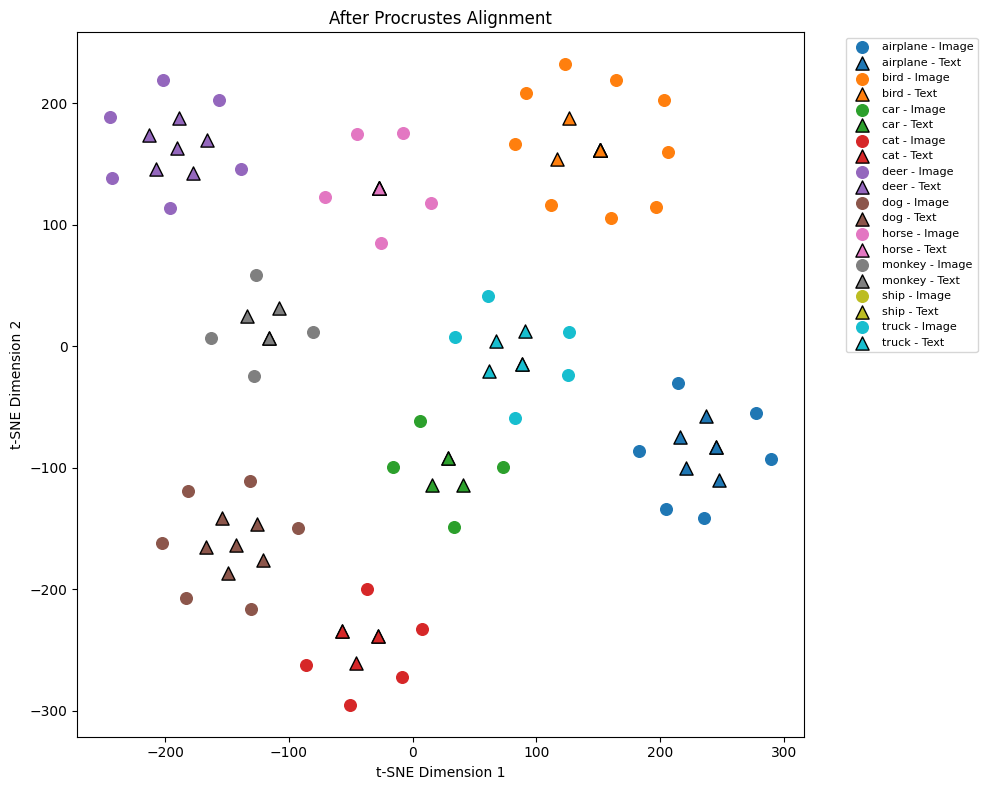

In [52]:
from scipy.linalg import orthogonal_procrustes

X = image_features.cpu().numpy()
Y = text_features.cpu().numpy()

R, scale = orthogonal_procrustes(X, Y)

X_transform = X @ R

concat_embeddings = np.concatenate([X_transform, Y], axis=0)

tsne = TSNE(n_components=2, random_state=2, perplexity=15)

aligned_2d = tsne.fit_transform(concat_embeddings)

plot_embeddings(aligned_2d, "After Procrustes Alignment")


In [54]:
text = clip.tokenize(plain_label).to(device)

with torch.no_grad():
    class_text_features = model.encode_text(text)

class_text_features = class_text_features.float()

class_text_features /= class_text_features.norm(dim=-1, keepdim=True)

correct = 0
total = 0

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        image_features = model.encode_image(images)

        image_features_np = image_features.cpu().numpy()

        aligned_features_np = image_features_np @ R

        aligned_features = torch.tensor(aligned_features_np, dtype=torch.float32, device=device)

        aligned_features /= aligned_features.norm(dim=-1, keepdim=True)

        similarity = aligned_features @ class_text_features.T

        predictions = similarity.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

print(f"Aligned CLIP accuracy: {accuracy:.2f}%")



Aligned CLIP accuracy: 85.72%


***TASK 4***

In [55]:
transform = transforms.ToTensor()

mnist_train = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 552kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


In [65]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)

        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self, output_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.relu = nn.ReLU()
        
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        h = self.relu(self.fc1(z))
        x_reconstructed = self.sigmoid(self.fc2(h))
        return x_reconstructed

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(input_dim, hidden_dim, latent_dim)
        
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decoder(z)
        return reconstructed, mu, log_var


import torch.nn.functional as F

def vae_loss(reconstructed, x, mu, log_var):
    x = torch.flatten(x, start_dim=1)
    recon_loss = F.binary_cross_entropy(reconstructed, x, reduction='sum')
    
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    total_loss = recon_loss + kl_div
    return total_loss, recon_loss, kl_div

In [68]:
vae_model = VAE(input_dim=784, hidden_dim=400, latent_dim=2)
vae_model = vae_model.to(device)

optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [69]:
EPCOHS = 10

for epoch in range(EPCOHS):

    vae_model.train()

    total_loss = 0.0

    for x, _ in train_loader:

        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = vae_model(x)

        loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{EPCOHS}] " f"Loss: {avg_loss:.4f}")

Epoch [1/10] Loss: 182.2671
Epoch [2/10] Loss: 165.9052
Epoch [3/10] Loss: 162.2133
Epoch [4/10] Loss: 160.0961
Epoch [5/10] Loss: 158.5674
Epoch [6/10] Loss: 157.4438
Epoch [7/10] Loss: 156.4346
Epoch [8/10] Loss: 155.6037
Epoch [9/10] Loss: 154.8182
Epoch [10/10] Loss: 154.1641


In [71]:
vae_model.eval()

latent_vectors = []
latent_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        mu, log_var = vae_model.encoder(images)

        latent_vectors.append(mu.cpu())
        latent_labels.append(labels)

latent_vectors = torch.cat(latent_vectors, dim=0)
latent_labels = torch.cat(latent_labels, dim=0)


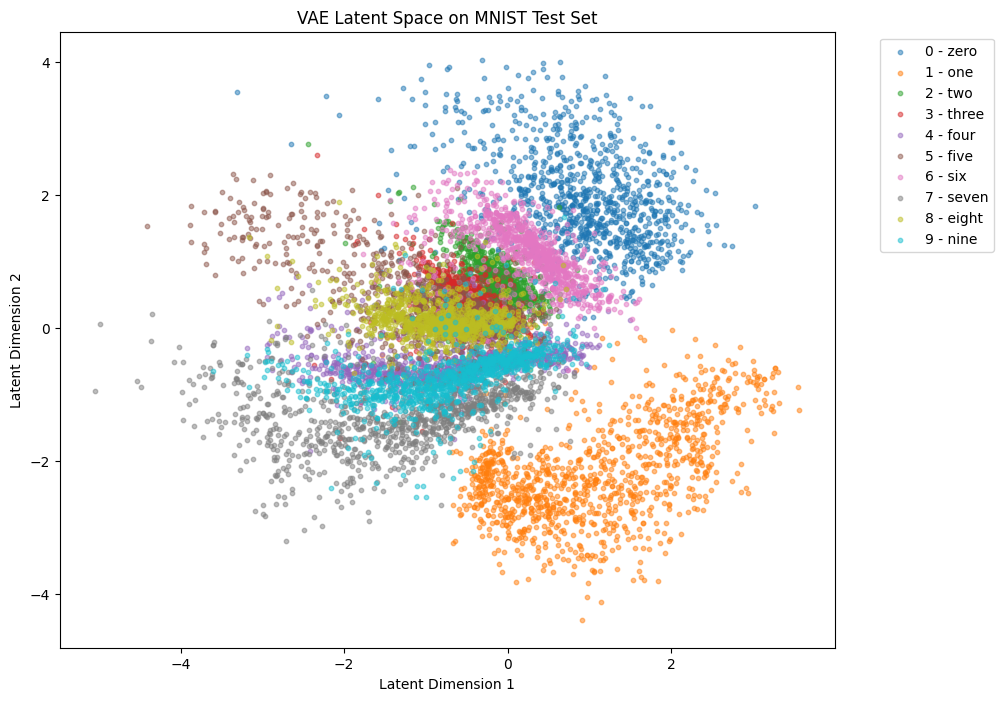

In [72]:
classes = mnist_train.classes

plt.figure(figsize=(10, 8))

for num in range(10):

    mask = latent_labels == num

    plt.scatter(latent_vectors[mask, 0], latent_vectors[mask, 1], label=classes[num], alpha=0.5, s=10)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space on MNIST Test Set")
plt.legend( bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

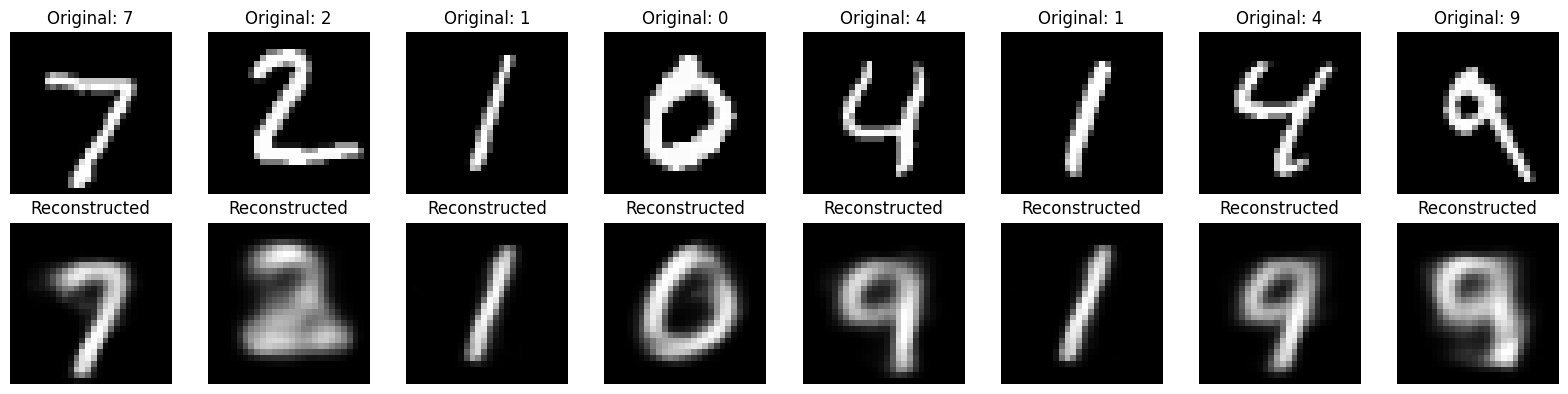

In [74]:
vae_model.eval()

images, labels = next(iter(test_loader))

images = images[:8].to(device)
labels = labels[:8]

with torch.no_grad():

    reconstructed, mu, log_var = vae_model(images)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original: {labels[i].item()}")

    axes[1, i].imshow(reconstructed[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstructed")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("VAE")

plt.tight_layout()
plt.show()

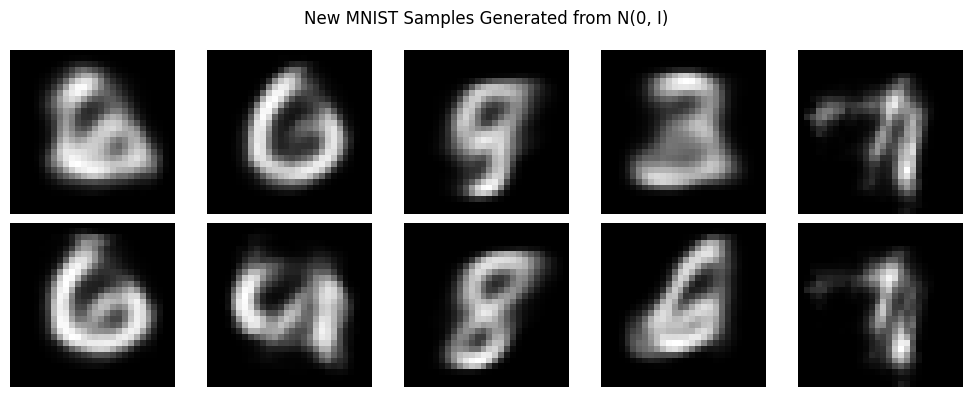

In [75]:
vae_model.eval()

with torch.no_grad():

    z = torch.randn(10, 2).to(device)

    generated = vae_model.decoder(z)

    generated = generated.view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):

    ax.imshow( generated[i].cpu(), cmap="gray")

    ax.axis("off")blob:vscode-webview://1rieqpabf10hud7v4g0b7e4k2md0t96lgru43rt3233q5m2gaa3g/442eccba-e2f6-4bab-84a0-2a4bcd17d04a

plt.suptitle("New MNIST Samples Generated from N(0, I)")
plt.tight_layout()
plt.show()